## Seção 1 — pandas: a carteira de seguros em forma de DataFrame

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

carteira = pd.DataFrame({
    "apolice_id": range(1, n + 1),
    "ramo": np.random.choice(["auto", "residencial", "vida"], size=n, p=[0.5, 0.3, 0.2]),
    "premio": np.random.lognormal(mean=7.0, sigma=0.5, size=n),  # 💡 lognormal é mais realista para prêmios
    "exposicao": np.random.uniform(0.1, 1.0, size=n),
    "sinistros": np.random.poisson(lam=0.3, size=n),
})

print(carteira.shape)
print(carteira.dtypes)
print(carteira.head())

(1000, 5)
apolice_id      int64
ramo              str
premio        float64
exposicao     float64
sinistros       int64
dtype: object
   apolice_id         ramo       premio  exposicao  sinistros
0           1         auto  1198.529300   0.974379          0
1           2         vida   562.464387   0.398212          1
2           3  residencial  1326.234398   0.533837          0
3           4  residencial  1488.155738   0.276488          0
4           5         auto  1450.836004   0.649702          1


In [2]:
# visão geral estatística da carteira
print(carteira.describe())

# filtrar apenas apólices com sinistro
com_sinistro = carteira[carteira["sinistros"] > 0]
print(f"Apólices com sinistro: {len(com_sinistro)} ({len(com_sinistro) / n:.1%})")

# prêmio médio por ramo
premio_medio = carteira.groupby("ramo")["premio"].mean().round(2)
print(premio_medio)

        apolice_id       premio    exposicao    sinistros
count  1000.000000  1000.000000  1000.000000  1000.000000
mean    500.500000  1300.731971     0.543608     0.275000
std     288.819436   671.963385     0.259797     0.545594
min       1.000000   254.506088     0.100010     0.000000
25%     250.750000   827.111544     0.327907     0.000000
50%     500.500000  1143.795542     0.539437     0.000000
75%     750.250000  1587.341852     0.764086     0.000000
max    1000.000000  5412.973136     0.998039     4.000000
Apólices com sinistro: 232 (23.2%)
ramo
auto           1307.20
residencial    1317.12
vida           1259.83
Name: premio, dtype: float64


In [3]:
carteira["frequencia"] = carteira["sinistros"] / carteira["exposicao"]

# ⚠️ exposicao zero gera divisão por infinito — trate antes se houver registros com exposicao = 0
carteira["loss_ratio"] = (carteira["sinistros"] * carteira["premio"].mean()) / carteira["premio"]

print(carteira[["apolice_id", "ramo", "frequencia", "loss_ratio"]].head(10))

   apolice_id         ramo  frequencia  loss_ratio
0           1         auto    0.000000    0.000000
1           2         vida    2.511223    2.312559
2           3  residencial    0.000000    0.000000
3           4  residencial    0.000000    0.000000
4           5         auto    1.539167    0.896540
5           6         auto    0.000000    0.000000
6           7         auto    3.492921    0.781704
7           8         vida    0.000000    0.000000
8           9  residencial    0.000000    0.000000
9          10  residencial    0.000000    0.000000


## Seção 2 — numpy: operações vetorizadas sobre dados de seguro

In [4]:
premios = np.array([1200.0, 3400.0, 800.0, 5600.0, 2100.0])
exposicoes = np.array([1.0, 0.75, 0.5, 1.0, 0.25])

# operações vetorizadas: sem loop, sem iteração manual
premios_anualizados = premios / exposicoes
print("Prêmios anualizados:", premios_anualizados.round(2))

print(f"Média:         {premios_anualizados.mean():.2f}")
print(f"Mediana:       {np.median(premios_anualizados):.2f}")
print(f"Desvio padrão: {premios_anualizados.std():.2f}")

Prêmios anualizados: [1200.   4533.33 1600.   5600.   8400.  ]
Média:         4266.67
Mediana:       4533.33
Desvio padrão: 2662.66


In [5]:
np.random.seed(42)

sinistros_simulados = np.random.poisson(lam=0.3, size=10_000)

print(f"Total de sinistros: {sinistros_simulados.sum()}")
print(f"Apólices sem sinistro: {(sinistros_simulados == 0).sum()} ({(sinistros_simulados == 0).mean():.1%})")
print(f"Percentis [50, 75, 90, 99]: {np.percentile(sinistros_simulados, [50, 75, 90, 99])}")

Total de sinistros: 2950
Apólices sem sinistro: 7455 (74.6%)
Percentis [50, 75, 90, 99]: [0. 1. 1. 2.]


## Seção 3 — matplotlib e seaborn: de número a decisão


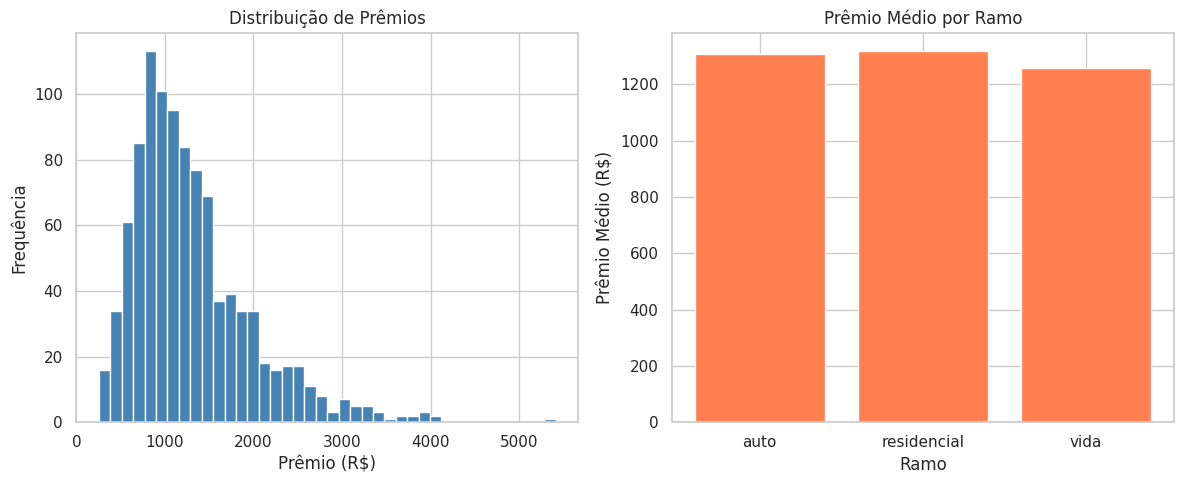

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(carteira["premio"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição de Prêmios")
axes[0].set_xlabel("Prêmio (R$)")
axes[0].set_ylabel("Frequência")

premio_ramo = carteira.groupby("ramo")["premio"].mean().reset_index()
axes[1].bar(premio_ramo["ramo"], premio_ramo["premio"], color="coral", edgecolor="white")
axes[1].set_title("Prêmio Médio por Ramo")
axes[1].set_xlabel("Ramo")
axes[1].set_ylabel("Prêmio Médio (R$)")

plt.tight_layout()
plt.savefig("distribuicao_premios_por_ramo.png", dpi=150, bbox_inches="tight")
plt.show()

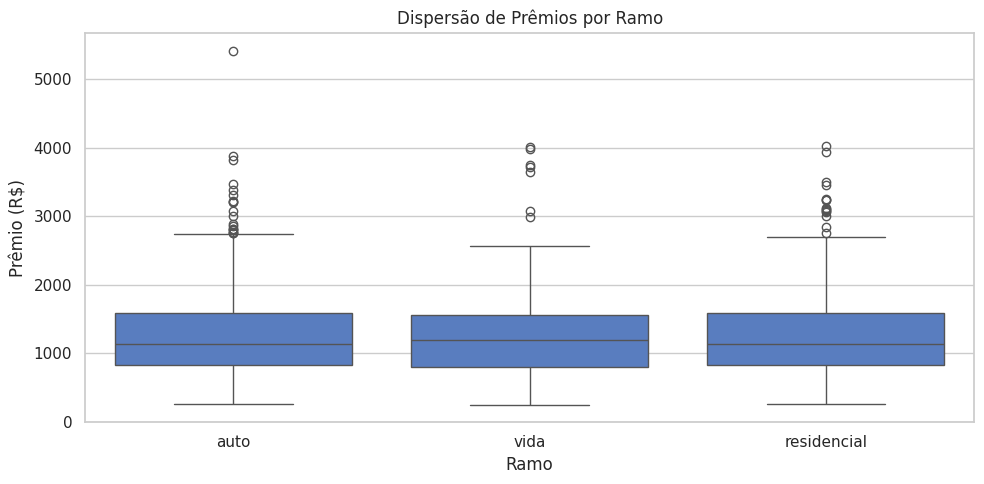

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=carteira, x="ramo", y="premio", ax=ax)
ax.set_title("Dispersão de Prêmios por Ramo")
ax.set_xlabel("Ramo")
ax.set_ylabel("Prêmio (R$)")

plt.tight_layout()
plt.savefig("boxplot_premios_ramo.png", dpi=150, bbox_inches="tight")
plt.show()